In [1]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from rebar_object_detection import get_bounding_boxes, get_lines
import json

[[     89.033      56.438]
 [     16.179      104.81]
 [     392.68      113.93]
 [     498.37      275.92]
 [     382.05      64.707]
 [     80.526      106.38]
 [      341.5      168.84]
 [     333.98      112.13]
 [     211.02       36.44]
 [     371.82       21.74]
 [     33.366       361.3]
 [     57.602       234.3]
 [     42.235      9.6574]
 [     293.85      521.68]
 [     84.902      80.703]
 [     206.11      358.71]
 [     208.54      136.92]
 [     102.68      527.33]
 [     376.72      41.837]
 [      456.7      407.54]
 [     404.96      169.89]
 [     208.06      166.72]
 [     591.89       170.1]
 [     119.53      359.86]
 [     529.73      170.66]
 [     208.02       200.3]
 [     477.72      202.23]
 [      553.6      458.49]
 [     109.21      464.01]
 [        152      34.859]
 [      327.7      63.936]
 [     149.74      57.863]
 [     373.87      409.01]
 [     266.69       17.76]
 [    0.10356       162.2]
 [     367.04      358.26]
 [     22.045      80.688]
 

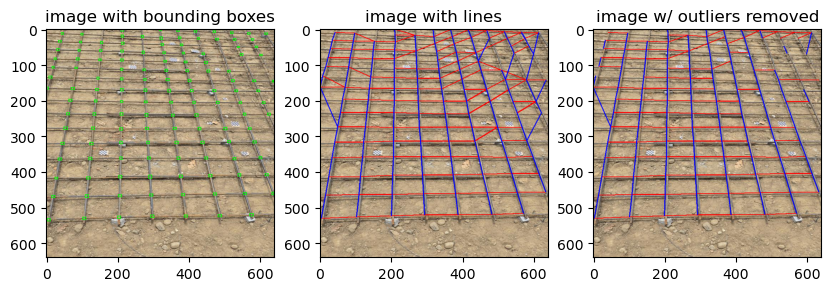

In [2]:
image_path = "data/intersect-detect/test/images/20250620_115012_jpg.rf.239a32ab7bcbefe30fb9f388607d7048.jpg"
image_path = "data/intersect-detect/test/images/20250620_114830_jpg.rf.5e2332d4c667c38b39dfc6d6839eddf1.jpg"
# image_path = "data/intersect-detect/test/images/20250620_113200_jpg.rf.c129e547c74634bf1848bf9ef225a321.jpg"
model_path = "runs/detect/tune/weights/best.pt"

image = Image.open(image_path)
image_with_bounding_boxes = image.copy()
draw_boxes = ImageDraw.Draw(image_with_bounding_boxes)

# Draw bounding boxes
bounding_boxes = get_bounding_boxes(image, model_path)
for box in bounding_boxes:
    draw_boxes.rectangle([box[0], box[1], box[2], box[3]], outline="lime", width=2)

# Draw lines
def draw_lines(image_path, model_path, threshold=0):
    image = Image.open(image_path).copy()
    draw_lines = ImageDraw.Draw(image)

    json_data = get_lines(image, model_path, threshold=threshold)
    data = json.loads(json_data)
    for shape in data["shapes"]:
        points = shape["points"]
        color = "red" if shape["orientation"] == "pc1" else "blue"
        draw_lines.line([tuple(points[0]), tuple(points[1])], fill=color, width=3)
    
    return image

plt.figure(figsize=(10, 5))
plt.subplot(1,3,1)
plt.title("image with bounding boxes")
plt.imshow(image_with_bounding_boxes)
plt.subplot(1,3,2)
plt.title("image with lines")
plt.imshow(draw_lines(image_path, model_path))
plt.subplot(1,3,3)
plt.title("image w/ outliers removed")
plt.imshow(draw_lines(image_path, model_path, threshold=1.5))